In [1]:
# ===============================================================
# Compare Pushforward Models vs pCN Posterior in KL Coordinates
# ===============================================================
import os, torch, numpy as np, h5py, scipy.io as sio, matplotlib.pyplot as plt
from scipy.stats import norm
from utilities import MatReader
from FNOmodel import CosineFNO2d, FNOTripletAdapter


In [3]:
# -------------------------------
# Configuration
# -------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
Nsol, Nobs = 64, 8 
pCN_ntotal = 800000
pushforward_paths = {
    "T1": "./../../Models/CosineFNO_cmON_fromjoint_w48_m32x32_d4_usemoredataB28_lr1e-3_E50_s42_64by64_20251120_2136.pth", # light data model
    # "T1": "./../../Models/CosineFNO_cmON_fromjoint_w48_m32x32_d4_usemoredataB20_lr1e-3_E60_s42_64by64_20251112_1431.pth", # light data model

}


file_data = "./../../Data/Experiment2/darcy_data_64by64_data.mat"
file_true = "./../../Data/Experiment2/true_data_Nsol64.mat"
file_KL = "./../../Data/Experiment2/darcy_data_noiseless_latentdim_KLmethod_inference_check_effect_numberof_datapoints_100_domainsize64by64.mat"


In [2]:
# -------------------------------
# Load Data (x,y)
# -------------------------------
with h5py.File(file_data, "r") as f:
    x = np.array(f["x"])  # (256,256,N)
    y = np.array(f["y"])  # (8,8,N)

# add observation noise
np.random.seed(42)
sigma_obs = 1e-3
y_noisy = y + np.random.normal(0, sigma_obs, size=y.shape)

# split into halves: first half used for training, second half for inference
n_total = x.shape[-1]
half = (90*n_total) // 100
debeug_length=128
DEBUG=False
if DEBUG==True:
    x_joint = np.moveaxis(x[:, :, half:half+debeug_length], -1, 0).astype(np.float32)
    y_joint = np.moveaxis(y_noisy[:, :, half:half+debeug_length], -1, 0).astype(np.float32)
else:
    x_joint = np.moveaxis(x[:, :, half:], -1, 0).astype(np.float32)
    y_joint = np.moveaxis(y_noisy[:, :, half:], -1, 0).astype(np.float32)

# -------------------------------
# Load true (x*, y†)
# -------------------------------
true_data = sio.loadmat(file_true)
x_true = true_data["x_true"].reshape(Nsol, Nsol)
y_dagger = true_data["y_true"].reshape(Nobs, Nobs)


In [ ]:
x_joint.shape

(20000, 64, 64)

In [4]:
# -------------------------------
# Load KL basis (Φ, λ)
# -------------------------------
reader = MatReader(file_KL)
phi = reader.read_field("Phi_ldim")     # shape (Nsol^2, latent_dim)
lambdas = reader.read_field("lambdas_ldim").squeeze()
phi_np = np.asarray(phi)
latent_dim = phi_np.shape[1]


In [23]:
import numpy as np
x_dummy=np.linspace(3,59,8)

In [24]:
x_dummy,y_dummy

array([ 3., 11., 19., 27., 35., 43., 51., 59.])

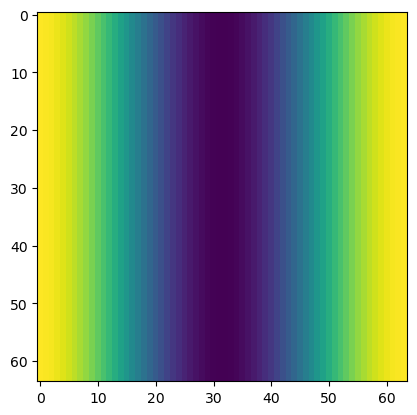

In [10]:
plt.imshow(phi[:,3].reshape(64,64))

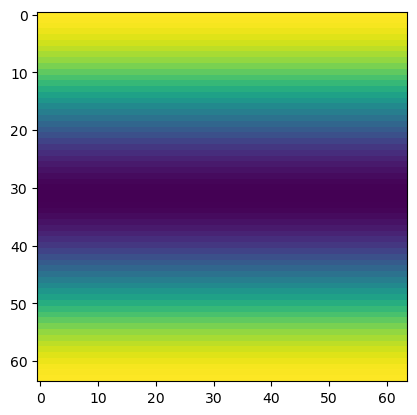

In [7]:
plt.imshow(phi[:,4].reshape(64,64))

In [5]:
# -------------------------------
# Load pCN posterior stats
# -------------------------------
save_dir = "./../../Data/Experiment2/"
proj_data = np.load(
    os.path.join(save_dir, f"pCN_projection_mean_variance_{pCN_ntotal}_samples_{Nsol}x{Nsol}.npy.npz")
)
pCN_mean = proj_data["projection_mean"]
pCN_var = proj_data["projection_variance"]


In [6]:
# -------------------------------
# Utility: load model checkpoint
# -------------------------------
def load_pushforward_model(path, device):
    checkpoint = torch.load(path, map_location=device)
    cfg = checkpoint["config"]
    base = CosineFNO2d(
        Cin=3, Cout=1, width=cfg["width"], modes_y=cfg["modes_y"], modes_x=cfg["modes_x"], Ly=1.0, Lx=1.0, depth=cfg["depth"],
        use_cm=cfg["use_cm"], cm_alpha=cfg["cm_alpha"], cm_tau=cfg["cm_tau"],
        dropout=cfg["dropout"]
    )
    model = FNOTripletAdapter(
        base,
        checkpoint["mean_std"]["mean_u"], checkpoint["mean_std"]["std_u"],
        checkpoint["mean_std"]["mean_y"], checkpoint["mean_std"]["std_y"]
    ).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model

models = {name: load_pushforward_model(path, device) for name, path in pushforward_paths.items()}


/tmp/ipykernel_87387/476786809.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=device)


In [7]:
# -------------------------------
# Prepare tensors for pushforward
# -------------------------------
u_joint = torch.from_numpy(x_joint.reshape(x_joint.shape[0], -1))
y_joint = torch.from_numpy(y_joint.reshape(y_joint.shape[0], -1))
y_dag = torch.from_numpy(y_dagger.reshape(1, -1).astype(np.float32))

# -------------------------------
# Pushforward through each model
# -------------------------------
@torch.no_grad()
def pushforward_samples(model, u_all, y_all, y_dag, batch_size=64):
    """Run model(u, y, y_dag) in safe batches to avoid OOM."""
    n = u_all.shape[0]
    results = []
    for i in range(0, n, batch_size):
        u_b = u_all[i:i+batch_size].to(device)
        y_b = y_all[i:i+batch_size].to(device)
        y_dag_b = y_dag.expand(u_b.shape[0], -1).to(device)

        out = model(u_b, y_b, y_dag_b).cpu()
        results.append(out)
        torch.cuda.empty_cache()  # clear GPU memory
    return torch.cat(results, dim=0).numpy()

print("Running pushforwards...")
samples_T1 = pushforward_samples(models["T1"], u_joint, y_joint, y_dag)
# samples_T2 = pushforward_samples(models["T2"], u_joint, y_joint, y_dag)
# samples_T3 = pushforward_samples(models["T3"], u_joint, y_joint, y_dag)


Running pushforwards...


: 

: 

In [ ]:
# -------------------------------
# Project samples onto KL modes
# -------------------------------
scale = 1.0 / (Nsol**2)
proj_T1 = samples_T1 @ phi_np * scale
# proj_T2 = samples_T2 @ phi_np * scale
# proj_T3 = samples_T3 @ phi_np * scale

In [ ]:
# -------------------------------
# Plot PDFs for first few KL modes
# -------------------------------
import seaborn as sns
sns.set(style="whitegrid")

import math, seaborn as sns
from scipy.stats import norm

def plot_pushforward_pdfs(
    proj_T1,
    phi, lambdas,
    pCN_mean, pCN_var,
    u_true_proj,
    n_modes_to_plot=8
):
    """
    Plots prior, pCN, T1, and T2 PDFs for the first `n_modes_to_plot` KL modes
    in one figure with subplots (4 columns, variable rows).
    """
    sns.set(style="whitegrid")
    n_cols = 4
    n_rows = math.ceil(n_modes_to_plot / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
    axes = axes.flatten()

    for i in range(n_modes_to_plot):
        ax = axes[i]

        # Range for PDFs
        x_min = min(
            proj_T1[:, i].min(),
            -4 * np.sqrt(lambdas[i])
        )
        x_max = max(
            proj_T1[:, i].max(),
            4 * np.sqrt(lambdas[i])
        )
        x_vals = np.linspace(x_min, x_max, 400)

        # ---- prior ----
        ax.plot(
            x_vals,
            norm.pdf(x_vals, 0, np.sqrt(lambdas[i])),
            "k-", lw=2, label="Prior N(0,λ)" if i == 0 else ""
        )

        # ---- pCN posterior ----
        ax.plot(
            x_vals,
            norm.pdf(x_vals, pCN_mean[i], np.sqrt(pCN_var[i])),
            "b--", lw=2, label="pCN" if i == 0 else ""
        )

        # ---- T1, T2 empirical PDFs ----
        sns.kdeplot(proj_T1[:, i], color="r", lw=2, ax=ax,
                    label="T₁ (cmOON)" if i == 0 else "")
        # sns.kdeplot(proj_T2[:, i], color="g", lw=2, ax=ax,
        #             label="T₂ (cmON)" if i == 0 else "")
        # sns.kdeplot(proj_T3[:, i], color="orange", lw=2, ax=ax,
        #     label="T₃ (cmON more data)" if i == 0 else "")
        # ---- true value ----
        ax.axvline(u_true_proj[i], color="cyan", linestyle="--", lw=2,
                   label="True value" if i == 0 else "")

        ax.set_title(f"KL mode {i+1}", fontsize=11)
        ax.set_xlabel("")
        ax.set_ylabel("PDF")

        if i == 0:
            ax.legend(frameon=False, fontsize=9)

    # Hide extra subplots
    for j in range(n_modes_to_plot, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


/tmp/ipykernel_79569/1373746957.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  -4 * np.sqrt(lambdas[i])
/tmp/ipykernel_79569/1373746957.py:37: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  4 * np.sqrt(lambdas[i])
/tmp/ipykernel_79569/1373746957.py:44: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  norm.pdf(x_vals, 0, np.sqrt(lambdas[i])),
/tmp/ipykernel_79569/1373746957.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  -4 * np.sqrt(lambdas[i])
/tmp/ipykernel_79569/1373746957.py:37: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
 

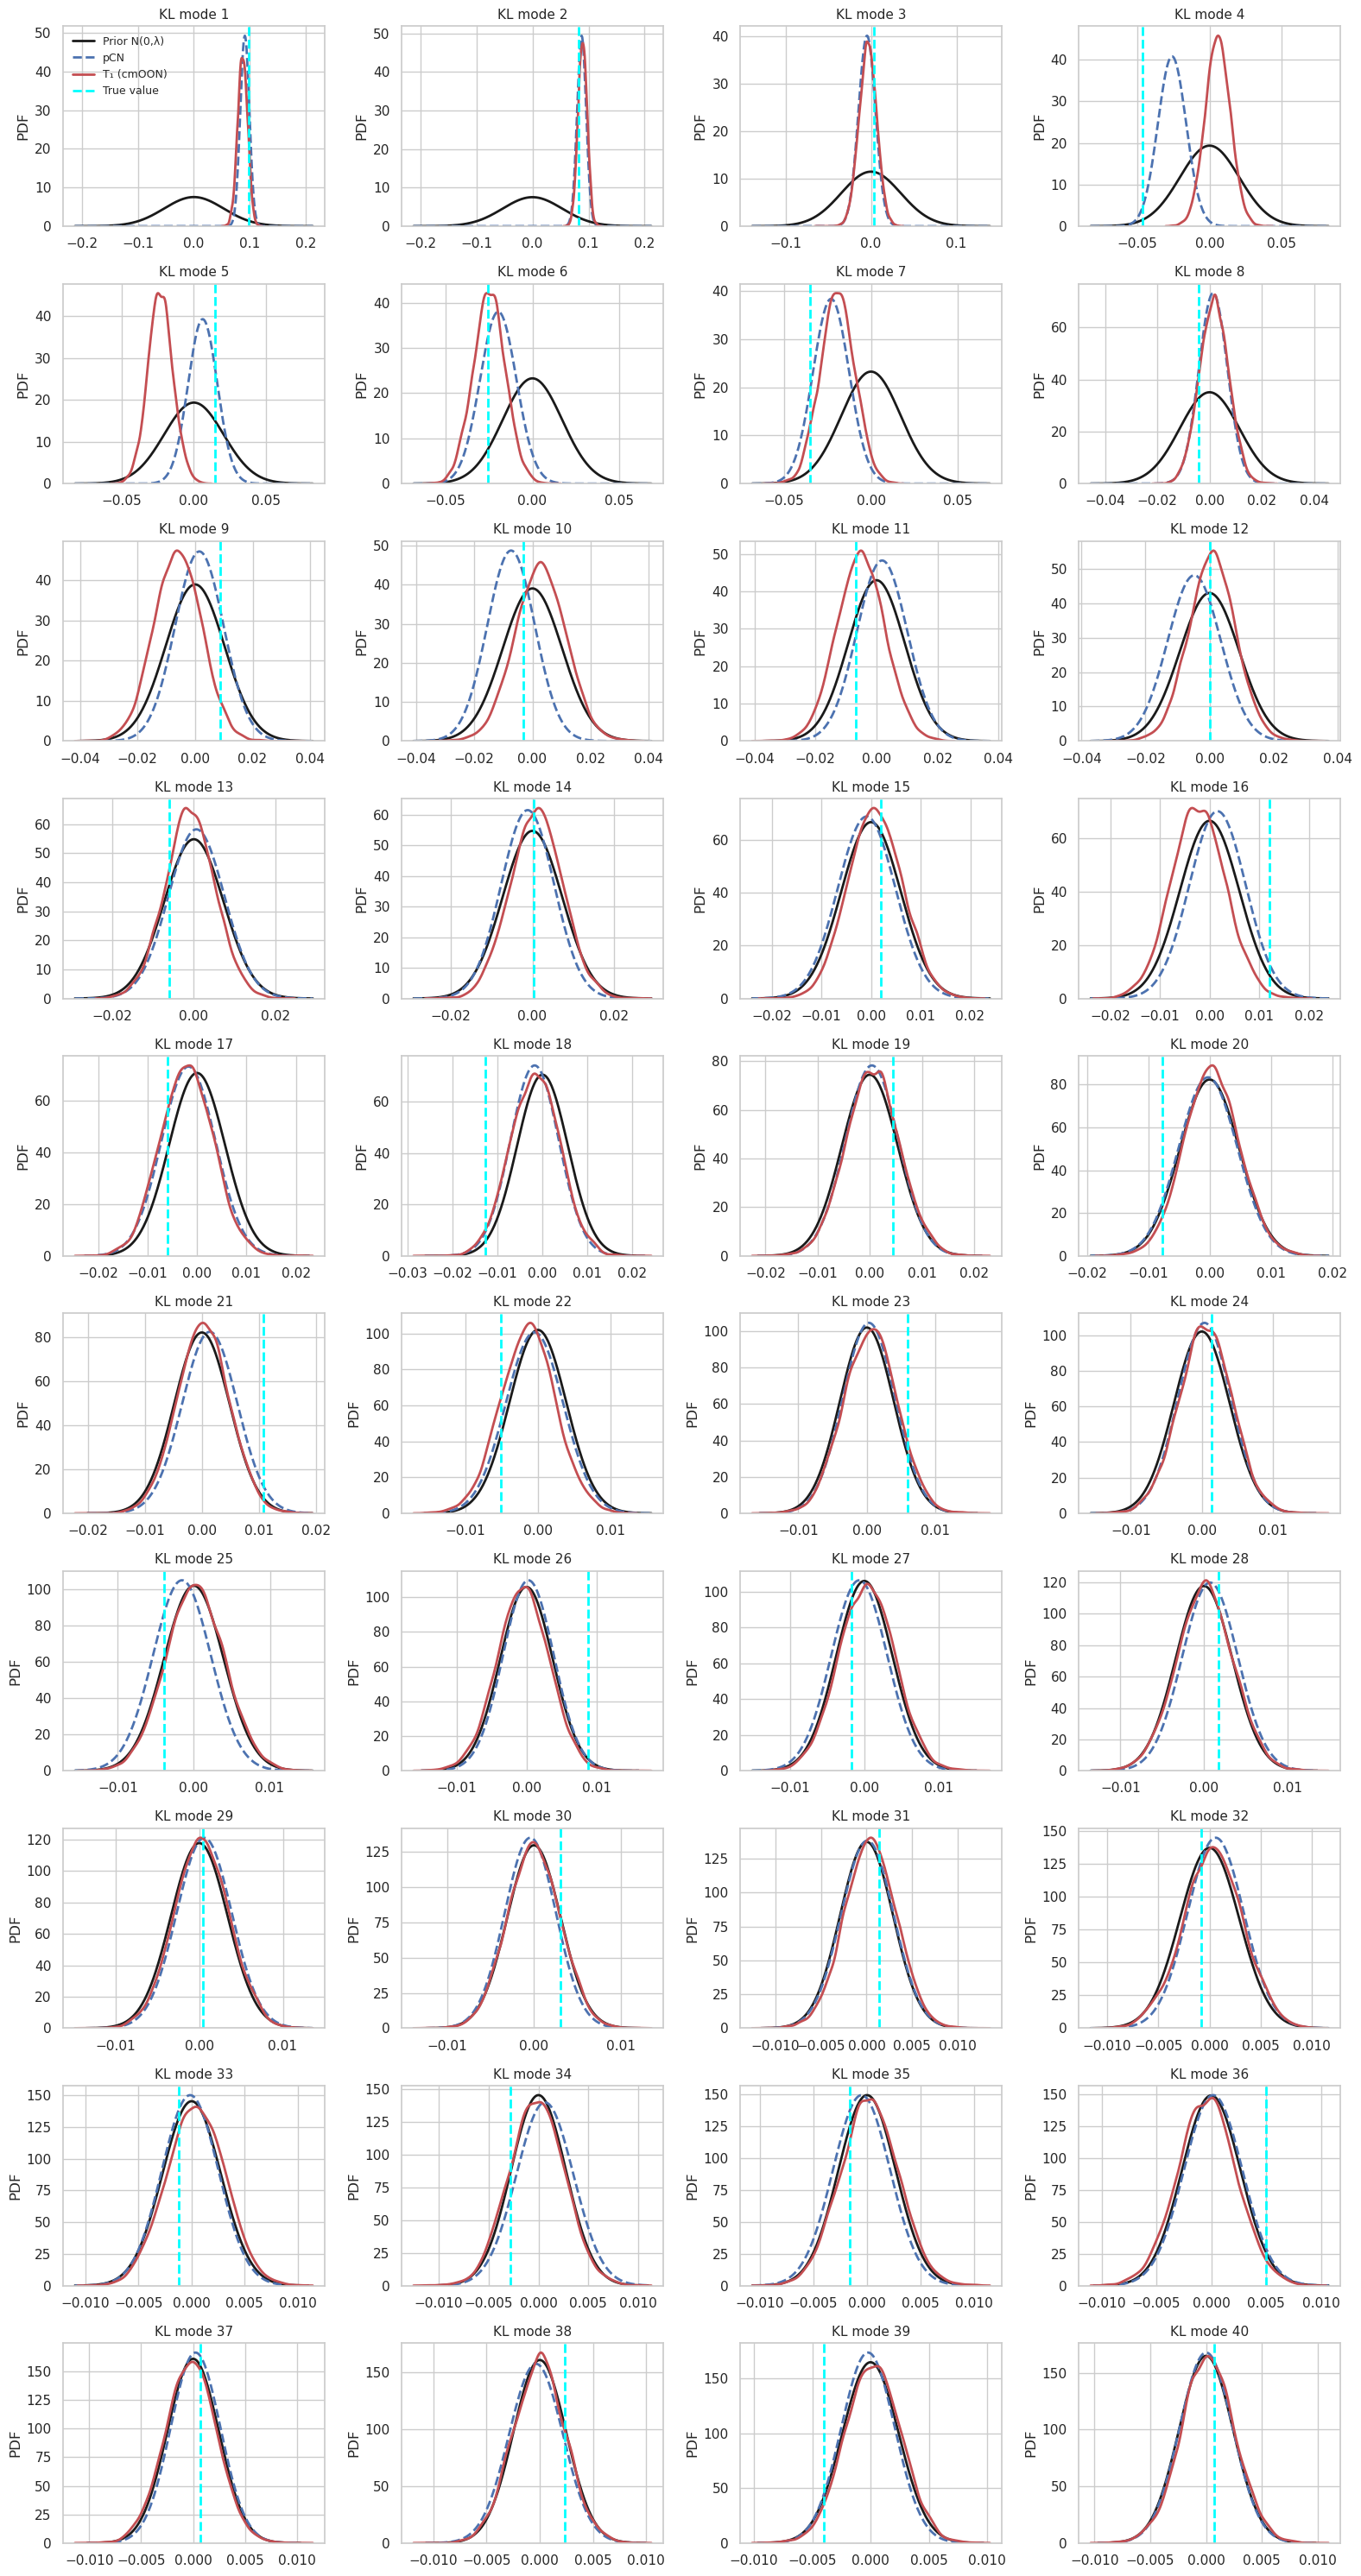

: 

In [ ]:
# ---- project true field onto KL basis ----
u_true_vec = x_true.reshape(1, -1)
u_true_proj = (u_true_vec @ phi_np) * (1.0 / Nsol**2)

# ---- plot first 8 KL modes ----
plot_pushforward_pdfs(
    proj_T1,
    phi_np, lambdas,
    pCN_mean, pCN_var,
    u_true_proj.squeeze(),
    n_modes_to_plot=40
)